In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import nltk
import warnings
%matplotlib inline

warnings.filterwarnings("ignore")

In [2]:
#load datasets

df = pd.read_csv("Twitter Sentiments.csv")
df.head()

,id,label,tweet
0,1,0,@user when a father is dysfunctional and is s...
1,2,0,@user @user thanks for #lyft credit i can't us...
2,3,0,bihday your majesty
3,4,0,#model i love u take with u all the time in ...
4,5,0,factsguide: society now #motivation


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31962 entries, 0 to 31961
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      31962 non-null  int64 
 1   label   31962 non-null  int64 
 2   tweet   31962 non-null  object
dtypes: int64(2), object(1)
memory usage: 749.2+ KB


# Preprocessing datasets

In [4]:
#remove pattern in input text

def remove_pattern(input_txt, pattern):
    r = re.findall(pattern, input_txt)
    
    for word in r:
        input_txt = re.sub(word, "", input_txt)

    return input_txt

#remove twitter handles(@user)

df["clean_tweet"] = np.vectorize(remove_pattern)(df["tweet"], "@[\w]*")

In [5]:
df.head()

,id,label,tweet,clean_tweet
0,1,0,@user when a father is dysfunctional and is s...,when a father is dysfunctional and is so sel...
1,2,0,@user @user thanks for #lyft credit i can't us...,thanks for #lyft credit i can't use cause th...
2,3,0,bihday your majesty,bihday your majesty
3,4,0,#model i love u take with u all the time in ...,#model i love u take with u all the time in ...
4,5,0,factsguide: society now #motivation,factsguide: society now #motivation


In [6]:
#remove special characters, num and punctuations

df["clean_tweet"] = df["clean_tweet"].str.replace("[^a-zA-Z#]", " ", regex = True)
df.head()

,id,label,tweet,clean_tweet
0,1,0,@user when a father is dysfunctional and is s...,when a father is dysfunctional and is so sel...
1,2,0,@user @user thanks for #lyft credit i can't us...,thanks for #lyft credit i can t use cause th...
2,3,0,bihday your majesty,bihday your majesty
3,4,0,#model i love u take with u all the time in ...,#model i love u take with u all the time in ...
4,5,0,factsguide: society now #motivation,factsguide society now #motivation


In [7]:
#remove short words
df["clean_tweet"] = df["clean_tweet"].apply(lambda x: " ".join([w for w in x.split() if len(w)>3]))
df.head()

,id,label,tweet,clean_tweet
0,1,0,@user when a father is dysfunctional and is s...,when father dysfunctional selfish drags kids i...
1,2,0,@user @user thanks for #lyft credit i can't us...,thanks #lyft credit cause they offer wheelchai...
2,3,0,bihday your majesty,bihday your majesty
3,4,0,#model i love u take with u all the time in ...,#model love take with time
4,5,0,factsguide: society now #motivation,factsguide society #motivation


In [8]:
# individual words considered as tokens
tokenized_tweet = df["clean_tweet"].apply(lambda x: x.split())
tokenized_tweet.head()

0    [when, father, dysfunctional, selfish, drags, ...
1    [thanks, #lyft, credit, cause, they, offer, wh...
2                              [bihday, your, majesty]
3                     [#model, love, take, with, time]
4                   [factsguide, society, #motivation]
Name: clean_tweet, dtype: object

In [9]:
# stem the words
from nltk.stem.porter import PorterStemmer
stemmer = PorterStemmer()

tokenized_tweet = tokenized_tweet.apply(lambda sentence: [stemmer.stem(word) for word in sentence])
tokenized_tweet.head() 

0    [when, father, dysfunct, selfish, drag, kid, i...
1    [thank, #lyft, credit, caus, they, offer, whee...
2                              [bihday, your, majesti]
3                     [#model, love, take, with, time]
4                         [factsguid, societi, #motiv]
Name: clean_tweet, dtype: object

In [10]:
#combine words into single string(sentence)
for i in range(len(tokenized_tweet)):
    tokenized_tweet[i] = " ".join(tokenized_tweet[i])

df["clean_tweet"] = tokenized_tweet
df.head()

,id,label,tweet,clean_tweet
0,1,0,@user when a father is dysfunctional and is s...,when father dysfunct selfish drag kid into dys...
1,2,0,@user @user thanks for #lyft credit i can't us...,thank #lyft credit caus they offer wheelchair ...
2,3,0,bihday your majesty,bihday your majesti
3,4,0,#model i love u take with u all the time in ...,#model love take with time
4,5,0,factsguide: society now #motivation,factsguid societi #motiv


# Exploratory Data Analysis

In [11]:
#!pip install wordcloud

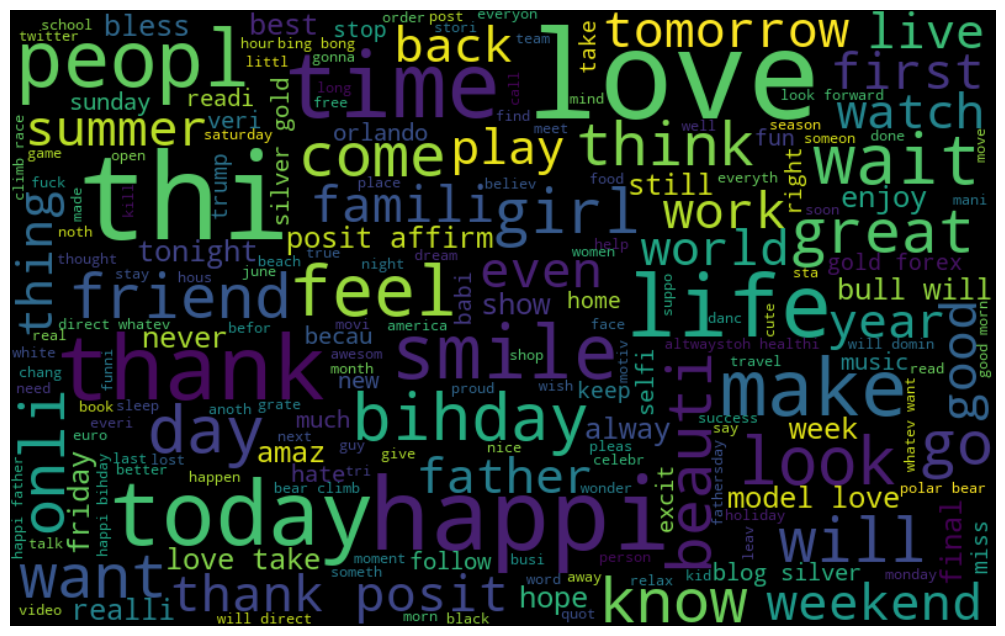

In [12]:
# visualize the frequent words
all_words = " ".join([sentence for sentence in df["clean_tweet"]])

from wordcloud import WordCloud
wordcloud = WordCloud(width = 800, height = 500, random_state = 42, max_font_size = 100).generate(all_words)

# plot the graph
plt.figure(figsize=(15,8))
plt.imshow(wordcloud, interpolation = "bilinear")
plt.axis("off")
plt.show()

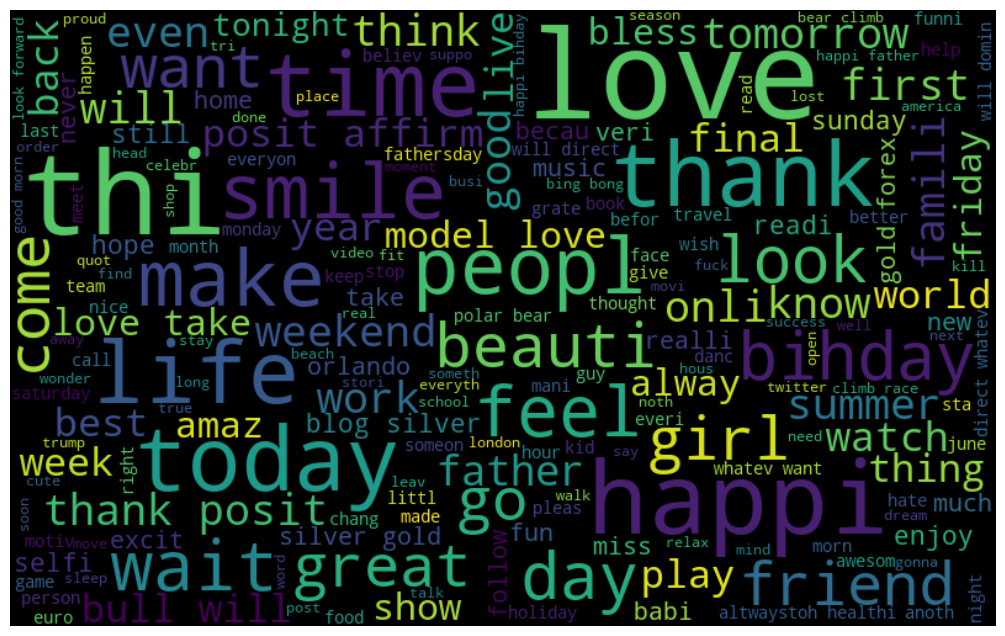

In [13]:
# visualize the +ve words
all_words = " ".join([sentence for sentence in df["clean_tweet"][df["label"]==0]])
  
wordcloud = WordCloud(width = 800, height = 500, random_state = 42, max_font_size = 100).generate(all_words)

# plot the graph
plt.figure(figsize=(15,8))
plt.imshow(wordcloud, interpolation = "bilinear")
plt.axis("off")
plt.show()

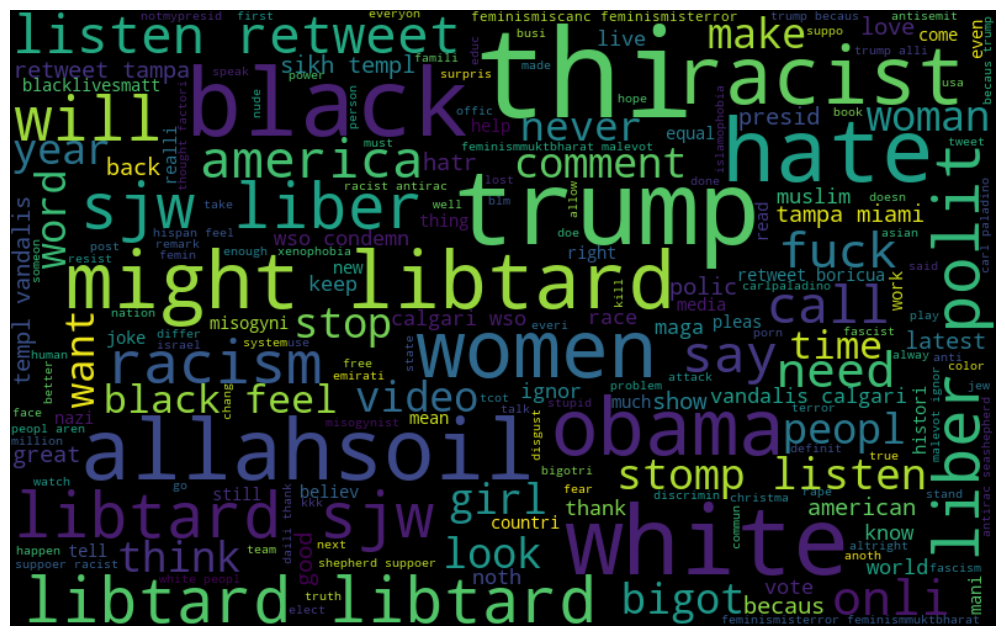

In [14]:
# visualize the -ve words
all_words = " ".join([sentence for sentence in df["clean_tweet"][df["label"]==1]])
  
wordcloud = WordCloud(width = 800, height = 500, random_state = 42, max_font_size = 100).generate(all_words)

# plot the graph
plt.figure(figsize=(15,8))
plt.imshow(wordcloud, interpolation = "bilinear")
plt.axis("off")
plt.show()

In [15]:
# extract the hashtag
def hashtag_extract(tweets):
    hashtags = []
    # Loop words in the tweet
    for tweet in tweets:
        ht = re.findall(r"#(\w++)", tweet)
        hashtags.append(ht)
    return hashtags

In [16]:
# extract hashtags from non-racist/sexist tweets
ht_positive = hashtag_extract(df["clean_tweet"][df["label"]==0])

# extract hashtags from racist/sexist tweets
ht_negative = hashtag_extract(df["clean_tweet"][df["label"]==1])

In [17]:
ht_positive[:5]

[['run'], ['lyft', 'disapoint', 'getthank'], [], ['model'], ['motiv']]

In [18]:
# unnest list
ht_positive = sum(ht_positive, [])
ht_negative = sum(ht_negative, [])

In [19]:
ht_positive[:5]

['run', 'lyft', 'disapoint', 'getthank', 'model']

In [20]:
freq = nltk.FreqDist(ht_positive)
d = pd.DataFrame({"Hashtag": list(freq.keys()), "Count": list(freq.values())})
d.head()

,Hashtag,Count
0,run,72
1,lyft,2
2,disapoint,1
3,getthank,2
4,model,375


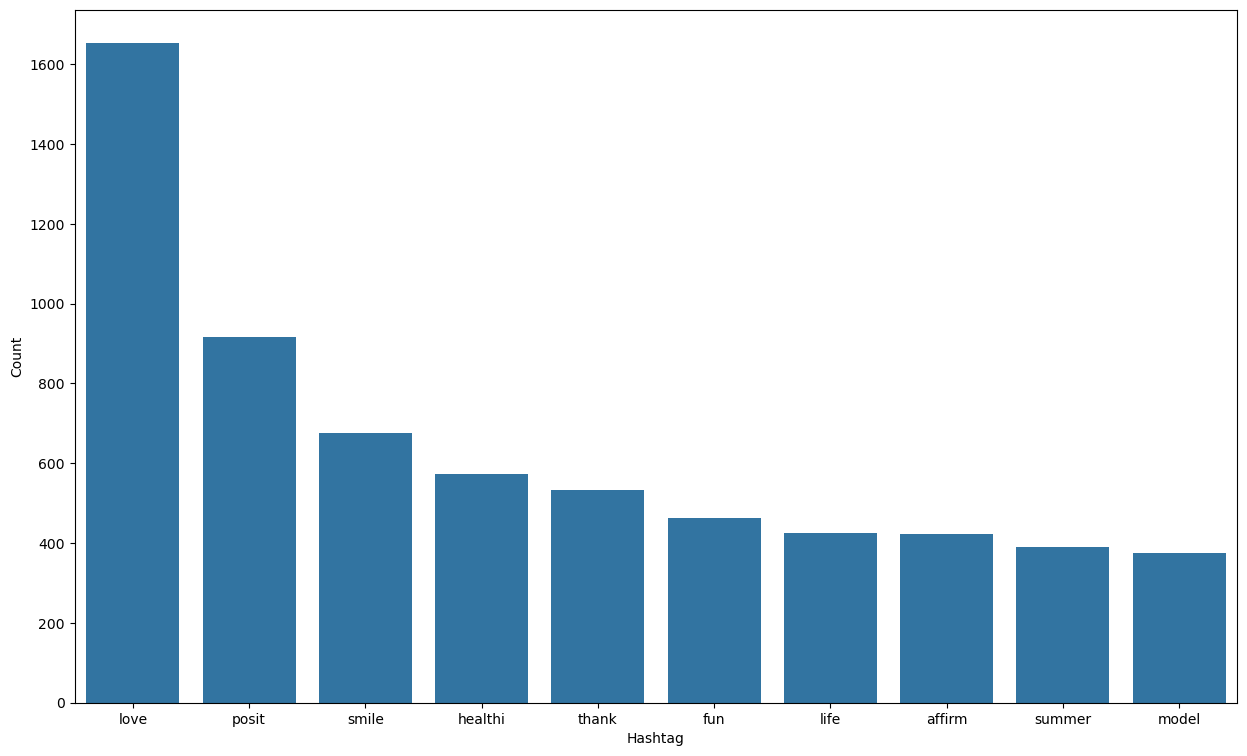

In [21]:
# select top 10 hashtags
d = d.nlargest(columns = "Count", n=10)
plt.figure(figsize=(15,9))
sns.barplot(data = d, x="Hashtag", y="Count")
plt.show()

In [22]:
freq = nltk.FreqDist(ht_negative)
d = pd.DataFrame({"Hashtag": list(freq.keys()), "Count": list(freq.values())})
d.head()

,Hashtag,Count
0,cnn,10
1,michigan,2
2,tcot,14
3,australia,6
4,opkillingbay,5


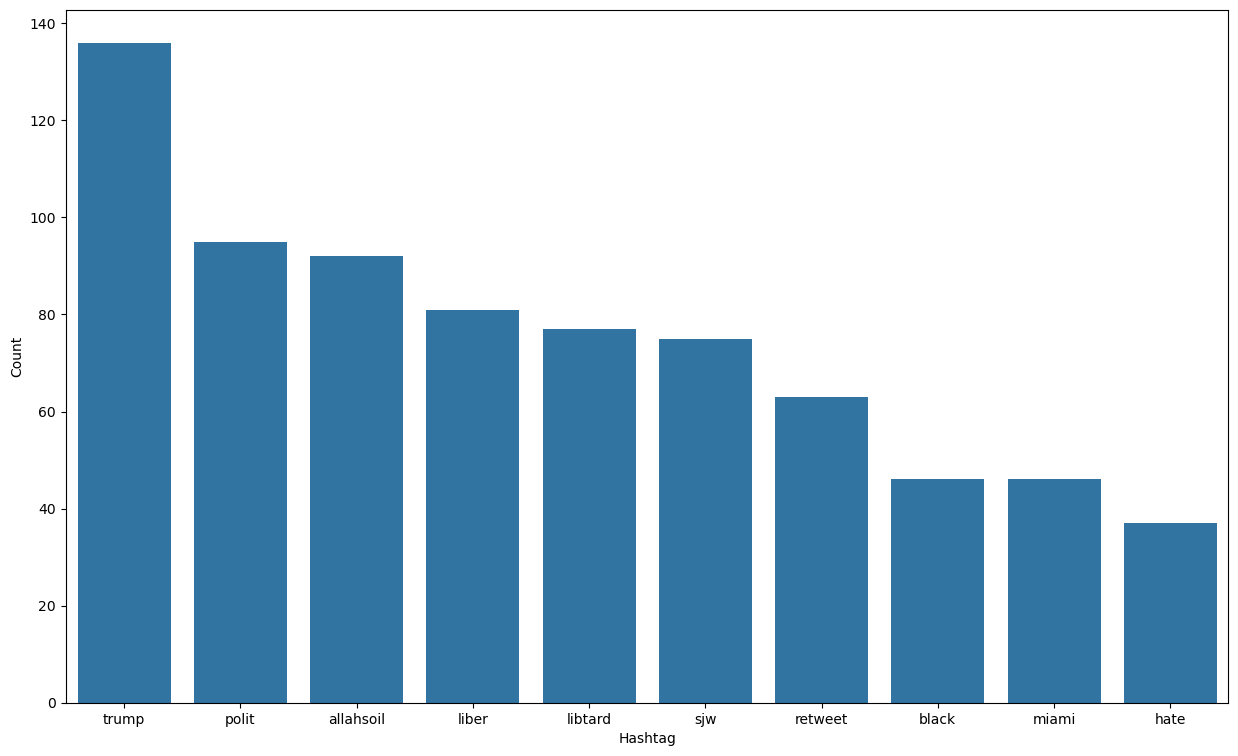

In [23]:
# select top 10 hashtags
d = d.nlargest(columns = "Count", n=10)
plt.figure(figsize=(15,9))
sns.barplot(data = d, x="Hashtag", y="Count")
plt.show()

# Feature extraction

In [24]:
#feature extraction

from sklearn.feature_extraction.text import CountVectorizer
bow_vectorizer = CountVectorizer(max_df = 0.90, min_df = 2, max_features = 1000, stop_words = "english")
bow = bow_vectorizer.fit_transform(df["clean_tweet"])                              

In [25]:
#split input for training and testing
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(bow, df["label"], random_state=42, test_size = 0.25)

# Model Training

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, accuracy_score

#training
model = LogisticRegression()
model.fit(x_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [27]:
#testing
pred = model.predict(x_test)
f1_score(y_test, pred)    

0.4970414201183432

In [28]:
accuracy_score(y_test, pred)

0.9468151670629458

In [29]:
# use probability to get output4
pred_prob = model.predict_proba(x_test)
pred = pred_prob[:, 1] >= 0.3
pred = pred.astype(np.int64)

f1_score(y_test, pred) 

0.5540275049115914

In [30]:
accuracy_score(y_test, pred)

0.943186084344888